<a href="https://colab.research.google.com/github/loreeente/JORGE-LORENTE-TFG/blob/main/Analisis%20del%20Dato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NOTEBOOK 02 - ANÁLISIS DEL DATO
# Pilar 2 del TFG: Modelado predictivo (clasificación + regresión)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ----- Librerías generales -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ----- Scikit-learn (clasificación + métricas) -----
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----- Configuración de gráficos -----
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 120,
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

print("Librerías cargadas ✔")
print(f"Pandas:       {pd.__version__}")
print(f"Numpy:        {np.__version__}")

Librerías cargadas ✔
Pandas:       2.2.2
Numpy:        2.0.2


In [3]:
# Carga del dataset maestro generado en el Notebook 01
DATA_DIR = '/content/drive/MyDrive/TFG_Lorente/output'

df = pd.read_csv(
    f'{DATA_DIR}/dataset_maestro.csv',
    parse_dates=['Date']  # ← muy importante para que pandas reconozca las fechas
)

print(f"Dataset cargado ✔")
print(f"Shape: {df.shape}")
print(f"Periodo: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Tickers: {sorted(df['Ticker'].unique())}")

Dataset cargado ✔
Shape: (14091, 37)
Periodo: 2020-10-14 → 2025-10-14
Tickers: ['BBVA', 'BKT', 'CABK', 'CLNX', 'ELE', 'IBE', 'MAP', 'NTGY', 'REP', 'SAB', 'SAN']


In [4]:
# Vista rápida del dataset
print("Primeras 3 filas:")
print(df.head(3))

print(f"\nNombres de columnas:")
for c in df.columns:
    print(f"  - {c}")

Primeras 3 filas:
        Date Ticker      Sector   Open   High    Low  Close      Volume  \
0 2020-10-14   BBVA  Financiero  2.260  2.313  2.248  2.268  38180000.0   
1 2020-10-15   BBVA  Financiero  2.223  2.269  2.183  2.257  19410000.0   
2 2020-10-16   BBVA  Financiero  2.278  2.347  2.210  2.334  20030000.0   

   PctChange  IPC_YoY  ...  Vol_60d  SMA_20  SMA_60  Mom_20  Mom_60  \
0     0.0044     -0.8  ...      NaN     NaN     NaN     NaN     NaN   
1    -0.0049     -0.8  ...      NaN     NaN     NaN     NaN     NaN   
2     0.0341     -0.8  ...      NaN     NaN     NaN     NaN     NaN   

   Target_Price_30d  Target_Return_30d  FutureMin_30d  MaxDrawdown_30d  \
0             3.785           0.668871          2.257        -0.004850   
1             3.770           0.670359          2.334         0.034116   
2             3.958           0.695801          2.339         0.002142   

   Target_Risk  
0            0  
1            0  
2            0  

[3 rows x 37 columns]

Nombres

In [5]:
# ============================================================
# PASO 15 - Selección de features y split temporal
# ============================================================

# Definimos las features (X) que vamos a usar en TODOS los modelos
FEAT_COLS = [
    # ----- TÉCNICAS (8) -----
    'LogReturn', 'Return_lag1', 'Return_lag5', 'Return_lag20',
    'Vol_20d', 'Vol_60d', 'Mom_20', 'Mom_60',
    # ----- MACROECONÓMICAS (4) -----
    'VIX', 'IPC_YoY', 'BCE_DFR', 'BCE_MRO',
    # ----- FUNDAMENTALES (3) -----
    'PE', 'ROE', 'DE'
]

print(f"Total features: {len(FEAT_COLS)}")
print(f"\nFamilias:")
print(f"  Técnicas:      8")
print(f"  Macro:         4")
print(f"  Fundamentales: 3")

# Validación crítica: ninguna feature es un target
target_cols = ['Target_Price_30d', 'Target_Return_30d', 'Target_Risk',
               'FutureMin_30d', 'MaxDrawdown_30d']
overlap = set(FEAT_COLS) & set(target_cols)
if overlap:
    print(f"\n⚠ ERROR: hay overlap entre features y targets: {overlap}")
else:
    print(f"\n✔ Validación: ninguna feature es un target. No hay data leakage.")

Total features: 15

Familias:
  Técnicas:      8
  Macro:         4
  Fundamentales: 3

✔ Validación: ninguna feature es un target. No hay data leakage.


In [7]:
# ----- Split temporal -----
SPLIT_DATE = pd.Timestamp('2024-06-01')

# Limpiamos primero las filas con NaN en las features o target
# (vienen del periodo de calentamiento de los lags y rolling)
clean = df.dropna(subset=FEAT_COLS + ['Target_Risk', 'Target_Price_30d']).copy()

# Split temporal (¡no aleatorio!)
train = clean[clean['Date'] <  SPLIT_DATE].copy()
test  = clean[clean['Date'] >= SPLIT_DATE].copy()

print(f"📊 Filas totales tras limpiar NaN: {len(clean):,}")
print(f"   (de {len(df):,} originales, perdimos {len(df) - len(clean):,} por warm-up de features)")

print(f"\n🎯 SPLIT TEMPORAL")
print(f"   Train: {len(train):,} filas  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"   Test:  {len(test):,} filas  ({test['Date'].min().date()} → {test['Date'].max().date()})")

print(f"\n⚖ Distribución del target en cada split:")
print(f"   Tasa de riesgo TRAIN: {train['Target_Risk'].mean()*100:.1f}%")
print(f"   Tasa de riesgo TEST:  {test['Target_Risk'].mean()*100:.1f}%")

# Validación de que no hay solapamiento de fechas
assert train['Date'].max() < test['Date'].min(), "❌ ERROR: solapamiento temporal!"
print(f"\n✔ Validación: train y test NO se solapan temporalmente.")

📊 Filas totales tras limpiar NaN: 13,101
   (de 14,091 originales, perdimos 990 por warm-up de features)

🎯 SPLIT TEMPORAL
   Train: 9,570 filas  (2021-01-08 → 2024-05-31)
   Test:  3,531 filas  (2024-06-03 → 2025-09-02)

⚖ Distribución del target en cada split:
   Tasa de riesgo TRAIN: 19.4%
   Tasa de riesgo TEST:  9.7%

✔ Validación: train y test NO se solapan temporalmente.


In [8]:
# Separamos X (features) e y (target) para train y test
X_train = train[FEAT_COLS].values
y_train = train['Target_Risk'].values

X_test  = test[FEAT_COLS].values
y_test  = test['Target_Risk'].values

print(f"X_train shape: {X_train.shape}  → {X_train.shape[0]:,} filas × {X_train.shape[1]} features")
print(f"y_train shape: {y_train.shape}  → vector binario (0/1)")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")

print(f"\n✔ Datos listos para modelar.")

X_train shape: (9570, 15)  → 9,570 filas × 15 features
y_train shape: (9570,)  → vector binario (0/1)
X_test  shape: (3531, 15)
y_test  shape: (3531,)

✔ Datos listos para modelar.


In [9]:
# ============================================================
# PASO 16 - Modelo A: Regresión Logística
# ============================================================

# ----- 1. Escalado de las features -----
# CRÍTICO: ajustamos el scaler SOLO con datos de train
scaler = StandardScaler()
scaler.fit(X_train)  # ← solo aprende media/std del TRAIN

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # ← aplica la misma transformación al test

print("Antes del escalado (X_train, primeras 3 filas, primeras 5 features):")
print(pd.DataFrame(X_train[:3, :5], columns=FEAT_COLS[:5]).round(3))

print("\nDespués del escalado (mismas filas, mismas features):")
print(pd.DataFrame(X_train_scaled[:3, :5], columns=FEAT_COLS[:5]).round(3))

print(f"\n✔ Features escaladas. Media de cada feature en train ≈ 0, std ≈ 1.")

Antes del escalado (X_train, primeras 3 filas, primeras 5 features):
   LogReturn  Return_lag1  Return_lag5  Return_lag20  Vol_20d
0     -0.018        0.010       -0.010         0.000    0.021
1     -0.006       -0.018        0.011        -0.025    0.020
2      0.001       -0.006       -0.001        -0.021    0.020

Después del escalado (mismas filas, mismas features):
   LogReturn  Return_lag1  Return_lag5  Return_lag20  Vol_20d
0     -1.002        0.516       -0.560        -0.029    0.637
1     -0.353       -1.002        0.549        -1.369    0.519
2      0.035       -0.354       -0.086        -1.155    0.413

✔ Features escaladas. Media de cada feature en train ≈ 0, std ≈ 1.


In [10]:
# ----- 2. Entrenamiento del modelo -----
log_reg = LogisticRegression(
    max_iter=2000,             # nº máximo de iteraciones (suele converger antes)
    class_weight='balanced',   # ← CRÍTICO por el desbalance (16% / 84%)
    random_state=42,           # reproducibilidad
    C=0.5                      # regularización moderada (1/C = fuerza de regularización)
)

log_reg.fit(X_train_scaled, y_train)

print("✔ Regresión Logística entrenada.")
print(f"   Coeficientes aprendidos: {len(log_reg.coef_[0])} (uno por feature)")
print(f"   Intercept: {log_reg.intercept_[0]:.3f}")

✔ Regresión Logística entrenada.
   Coeficientes aprendidos: 15 (uno por feature)
   Intercept: -0.163


In [11]:
# ----- 3. Predicciones sobre el test set -----
y_pred_lr       = log_reg.predict(X_test_scaled)             # 0 o 1
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]  # probabilidad de la clase 1

print(f"Predicciones generadas: {len(y_pred_lr):,}")
print(f"\nDistribución de predicciones:")
print(f"   Predijo 'sin riesgo' (0): {(y_pred_lr==0).sum():,} ({(y_pred_lr==0).mean()*100:.1f}%)")
print(f"   Predijo 'con riesgo' (1): {(y_pred_lr==1).sum():,} ({(y_pred_lr==1).mean()*100:.1f}%)")

print(f"\nDistribución de probabilidades:")
print(f"   Min: {y_pred_proba_lr.min():.3f}")
print(f"   Max: {y_pred_proba_lr.max():.3f}")
print(f"   Media: {y_pred_proba_lr.mean():.3f}")

Predicciones generadas: 3,531

Distribución de predicciones:
   Predijo 'sin riesgo' (0): 3,198 (90.6%)
   Predijo 'con riesgo' (1): 333 (9.4%)

Distribución de probabilidades:
   Min: 0.069
   Max: 0.725
   Media: 0.331


In [12]:
# ----- 4. Métricas -----
print("=" * 55)
print("MÉTRICAS — REGRESIÓN LOGÍSTICA (Modelo A baseline)")
print("=" * 55)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print(f"\n--- Reporte de clasificación detallado ---")
print(classification_report(y_test, y_pred_lr,
                            target_names=['Sin riesgo (0)', 'Con riesgo (1)'],
                            digits=4))

MÉTRICAS — REGRESIÓN LOGÍSTICA (Modelo A baseline)

Accuracy:  0.8720
Precision: 0.3363
Recall:    0.3265
F1-Score:  0.3314
AUC:       0.6376

--- Reporte de clasificación detallado ---
                precision    recall  f1-score   support

Sin riesgo (0)     0.9278    0.9307    0.9292      3188
Con riesgo (1)     0.3363    0.3265    0.3314       343

      accuracy                         0.8720      3531
     macro avg     0.6321    0.6286    0.6303      3531
  weighted avg     0.8703    0.8720    0.8711      3531



In [13]:
# ============================================================
# PASO 17 - Modelo B: Random Forest
# ============================================================

# ----- 1. Entrenamiento -----
rf = RandomForestClassifier(
    n_estimators=300,         # nº de árboles del bosque
    max_depth=8,              # profundidad máxima de cada árbol (control de overfitting)
    min_samples_leaf=20,      # mínimo de muestras por hoja (más robusto)
    class_weight='balanced',  # ← CRÍTICO igual que en Logistic
    random_state=42,          # reproducibilidad
    n_jobs=-1                 # paraleliza usando todos los cores disponibles
)

# Random Forest NO necesita escalado: usamos X_train directamente
rf.fit(X_train, y_train)

print("✔ Random Forest entrenado.")
print(f"   Número de árboles: {rf.n_estimators}")
print(f"   Profundidad máxima: {rf.max_depth}")

✔ Random Forest entrenado.
   Número de árboles: 300
   Profundidad máxima: 8


In [14]:
# ----- 2. Predicciones -----
y_pred_rf       = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# ----- 3. Métricas -----
print("=" * 55)
print("MÉTRICAS — RANDOM FOREST (Modelo B avanzado)")
print("=" * 55)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print(f"\n--- Reporte de clasificación detallado ---")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Sin riesgo (0)', 'Con riesgo (1)'],
                            digits=4))

MÉTRICAS — RANDOM FOREST (Modelo B avanzado)

Accuracy:  0.8417
Precision: 0.0814
Recall:    0.0612
F1-Score:  0.0699
AUC:       0.6267

--- Reporte de clasificación detallado ---
                precision    recall  f1-score   support

Sin riesgo (0)     0.9016    0.9257    0.9135      3188
Con riesgo (1)     0.0814    0.0612    0.0699       343

      accuracy                         0.8417      3531
     macro avg     0.4915    0.4934    0.4917      3531
  weighted avg     0.8219    0.8417    0.8315      3531



In [15]:
# ----- 4. Comparativa cara a cara -----
def metricas_dict(name, y_true, y_pred, y_proba):
    return {
        'Modelo':    name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'AUC':       round(roc_auc_score(y_true, y_proba), 4)
    }

comparativa = pd.DataFrame([
    metricas_dict('Logistic Regression', y_test, y_pred_lr, y_pred_proba_lr),
    metricas_dict('Random Forest',       y_test, y_pred_rf, y_pred_proba_rf)
])

print("=" * 75)
print("COMPARATIVA — CLASIFICACIÓN DE RIESGO")
print("=" * 75)
print(comparativa.to_string(index=False))

# Identificamos el ganador en cada métrica
print(f"\n🏆 GANADOR POR MÉTRICA:")
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']:
    idx_max = comparativa[col].idxmax()
    print(f"   {col:10s}: {comparativa.loc[idx_max, 'Modelo']} ({comparativa.loc[idx_max, col]:.4f})")

COMPARATIVA — CLASIFICACIÓN DE RIESGO
             Modelo  Accuracy  Precision  Recall  F1-Score    AUC
Logistic Regression    0.8720     0.3363  0.3265    0.3314 0.6376
      Random Forest    0.8417     0.0814  0.0612    0.0699 0.6267

🏆 GANADOR POR MÉTRICA:
   Accuracy  : Logistic Regression (0.8720)
   Precision : Logistic Regression (0.3363)
   Recall    : Logistic Regression (0.3265)
   F1-Score  : Logistic Regression (0.3314)
   AUC       : Logistic Regression (0.6376)


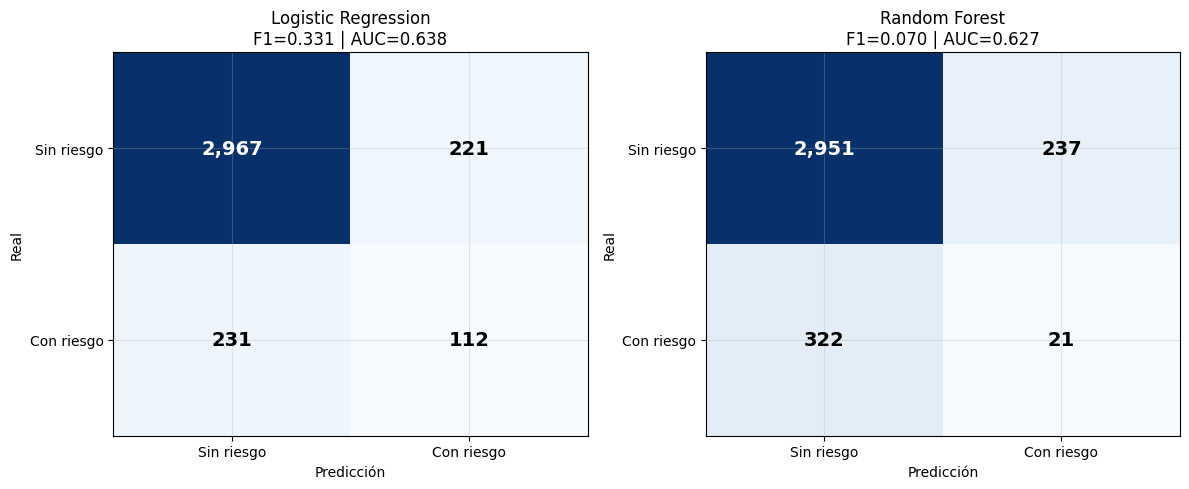

In [16]:
# ============================================================
# PASO 18 - Visualizaciones de los modelos de clasificación
# ============================================================

# ----- 1. Matrices de confusión (lado a lado) -----
import os
FIGS_DIR = '/content/drive/MyDrive/TFG_Lorente/figs'
os.makedirs(FIGS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos_info = [
    ('Logistic Regression', y_pred_lr, y_pred_proba_lr),
    ('Random Forest',       y_pred_rf, y_pred_proba_rf)
]

for ax, (nombre, y_pred, y_proba) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Sin riesgo', 'Con riesgo'])
    ax.set_yticklabels(['Sin riesgo', 'Con riesgo'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ax.set_title(f'{nombre}\nF1={f1:.3f} | AUC={auc:.3f}')

    # Anotaciones numéricas dentro de las celdas
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    color=color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/06_confusion_matrices.png', bbox_inches='tight')
plt.show()

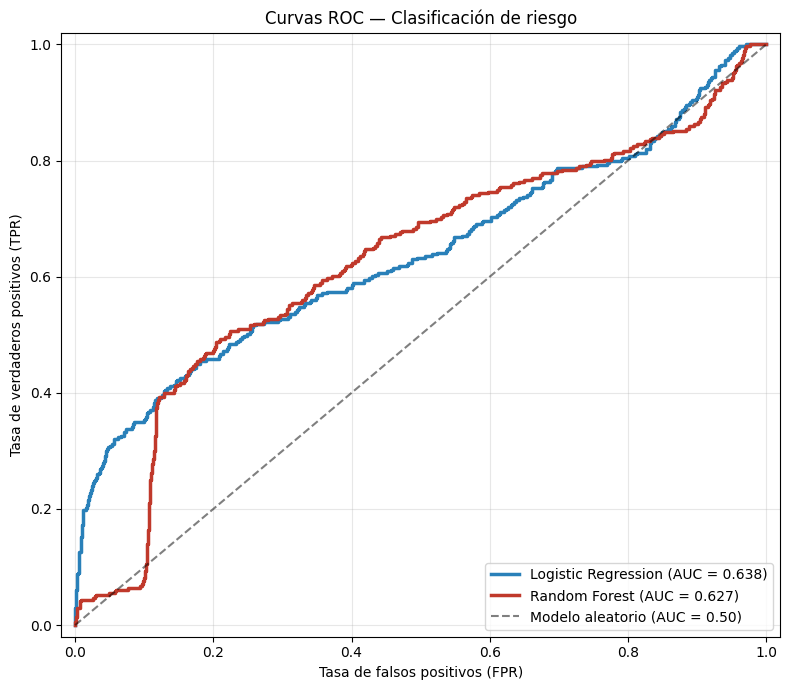

In [17]:
# ----- 2. Curvas ROC -----
fig, ax = plt.subplots(figsize=(8, 7))

for nombre, y_proba, color in [
    ('Logistic Regression', y_pred_proba_lr, '#2980b9'),
    ('Random Forest',       y_pred_proba_rf, '#c0392b')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{nombre} (AUC = {auc:.3f})')

# Línea de referencia: clasificador aleatorio
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Modelo aleatorio (AUC = 0.50)')

ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curvas ROC — Clasificación de riesgo')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/07_roc_curves.png', bbox_inches='tight')
plt.show()

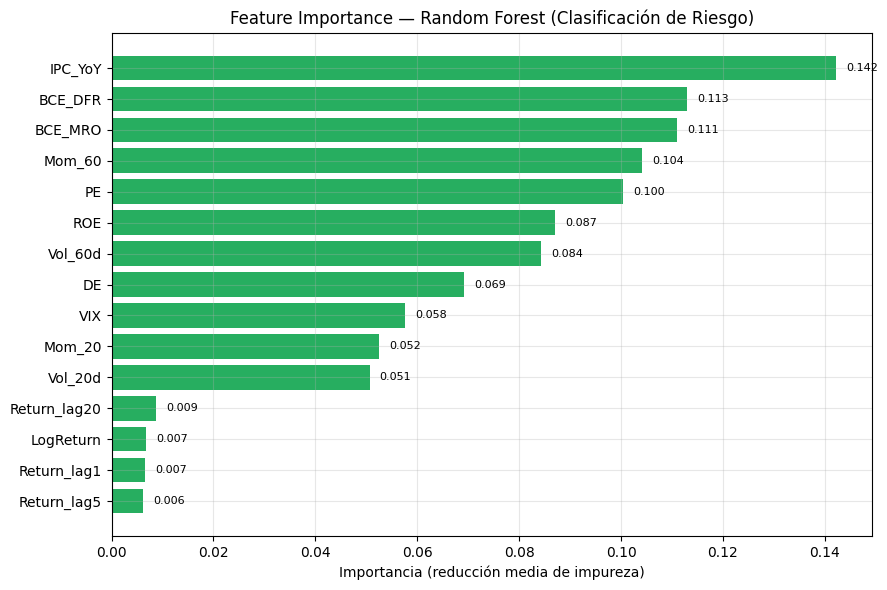


TOP 5 features según Random Forest:
Feature  Importance
IPC_YoY    0.142142
BCE_DFR    0.112859
BCE_MRO    0.111057
 Mom_60    0.104136
     PE    0.100365


In [18]:
# ----- 3. Feature importance del Random Forest -----
imp = pd.DataFrame({
    'Feature': FEAT_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance')  # ascendente para que el barh quede ordenado

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp['Feature'], imp['Importance'], color='#27ae60')
ax.set_xlabel('Importancia (reducción media de impureza)')
ax.set_title('Feature Importance — Random Forest (Clasificación de Riesgo)')

# Anotaciones numéricas en las barras
for i, v in enumerate(imp['Importance']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/08_feature_importance_rf.png', bbox_inches='tight')
plt.show()

print("\nTOP 5 features según Random Forest:")
print(imp.tail(5)[::-1].to_string(index=False))

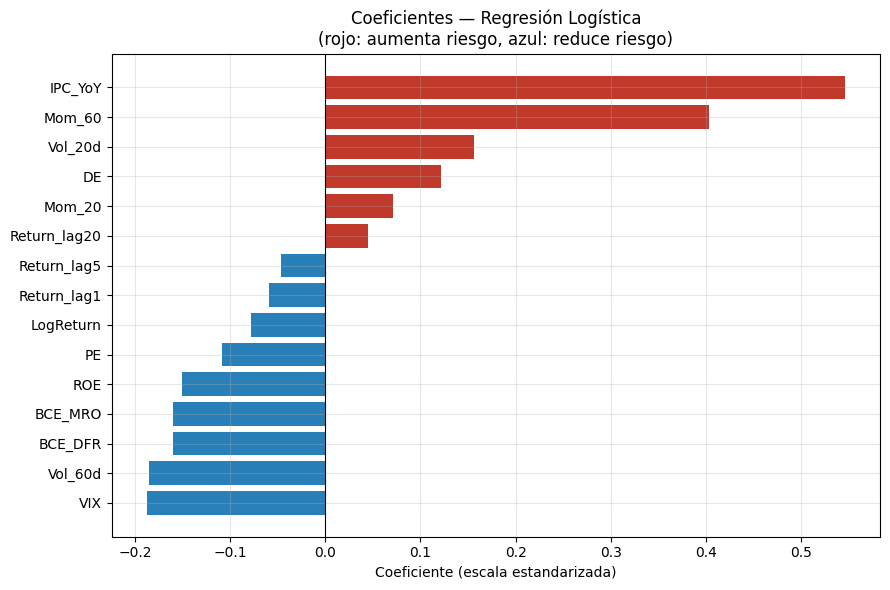


📈 Top 3 features que AUMENTAN el riesgo:
Feature     Coef
IPC_YoY 0.546354
 Mom_60 0.402875
Vol_20d 0.156610

📉 Top 3 features que REDUCEN el riesgo:
Feature      Coef
    VIX -0.188025
Vol_60d -0.185587
BCE_DFR -0.160215


In [19]:
# ----- 4. Coeficientes de la Regresión Logística -----
coefs = pd.DataFrame({
    'Feature': FEAT_COLS,
    'Coef': log_reg.coef_[0]
}).sort_values('Coef')

fig, ax = plt.subplots(figsize=(9, 6))
colores_coef = ['#c0392b' if v > 0 else '#2980b9' for v in coefs['Coef']]
ax.barh(coefs['Feature'], coefs['Coef'], color=colores_coef)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title('Coeficientes — Regresión Logística\n(rojo: aumenta riesgo, azul: reduce riesgo)')

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/09_logistic_coefs.png', bbox_inches='tight')
plt.show()

print("\n📈 Top 3 features que AUMENTAN el riesgo:")
print(coefs.tail(3)[::-1].to_string(index=False))

print("\n📉 Top 3 features que REDUCEN el riesgo:")
print(coefs.head(3).to_string(index=False))

In [20]:
# ============================================================
# PASO 19 - Tarea B: Regresión con ARIMA
# ============================================================

# Importamos statsmodels (debería venir preinstalado en Colab)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

print("✔ statsmodels importado")

# Elegimos un ticker representativo
TICKER_REG = 'BBVA'

# Filtramos solo BBVA y nos quedamos con la serie de precios
serie_bbva = (df[df['Ticker'] == TICKER_REG]
                .sort_values('Date')
                .set_index('Date')['Close'])

print(f"\nSerie de {TICKER_REG}:")
print(f"  Observaciones: {len(serie_bbva):,}")
print(f"  Periodo: {serie_bbva.index.min().date()} → {serie_bbva.index.max().date()}")
print(f"  Precio min: {serie_bbva.min():.3f}€")
print(f"  Precio max: {serie_bbva.max():.3f}€")
print(f"\nPrimeros 5 valores:")
print(serie_bbva.head())

✔ statsmodels importado

Serie de BBVA:
  Observaciones: 1,281
  Periodo: 2020-10-14 → 2025-10-14
  Precio min: 2.257€
  Precio max: 16.480€

Primeros 5 valores:
Date
2020-10-14    2.268
2020-10-15    2.257
2020-10-16    2.334
2020-10-19    2.356
2020-10-20    2.428
Name: Close, dtype: float64


In [21]:
def test_estacionariedad(serie, nombre):
    """
    Test Augmented Dickey-Fuller.
    H0: la serie NO es estacionaria (tiene raíz unitaria)
    H1: la serie ES estacionaria
    Si p-value < 0.05 → rechazamos H0 → es estacionaria
    """
    resultado = adfuller(serie.dropna())
    print(f"\n{nombre}:")
    print(f"  ADF Statistic: {resultado[0]:.4f}")
    print(f"  p-value:       {resultado[1]:.4f}")
    if resultado[1] > 0.05:
        print(f"  → ❌ NO estacionaria (p > 0.05)")
    else:
        print(f"  → ✔ Estacionaria (p < 0.05)")

# Test sobre la serie original
print("=" * 55)
print("TEST DE ESTACIONARIEDAD")
print("=" * 55)
test_estacionariedad(serie_bbva, 'Serie original (precios)')

# Diferenciamos una vez (d=1) y volvemos a testear
serie_diff = serie_bbva.diff().dropna()
test_estacionariedad(serie_diff, 'Serie diferenciada (d=1)')

TEST DE ESTACIONARIEDAD

Serie original (precios):
  ADF Statistic: 0.4133
  p-value:       0.9820
  → ❌ NO estacionaria (p > 0.05)

Serie diferenciada (d=1):
  ADF Statistic: -11.4943
  p-value:       0.0000
  → ✔ Estacionaria (p < 0.05)


In [22]:
# Split temporal de la serie (igual que para clasificación)
train_serie = serie_bbva[serie_bbva.index <  SPLIT_DATE]
test_serie  = serie_bbva[serie_bbva.index >= SPLIT_DATE]

print(f"Train: {len(train_serie):,} obs ({train_serie.index.min().date()} → {train_serie.index.max().date()})")
print(f"Test:  {len(test_serie):,} obs ({test_serie.index.min().date()} → {test_serie.index.max().date()})")
print(f"\nPrecio inicial train: {train_serie.iloc[0]:.3f}€")
print(f"Precio final train:   {train_serie.iloc[-1]:.3f}€")
print(f"Precio inicial test:  {test_serie.iloc[0]:.3f}€")
print(f"Precio final test:    {test_serie.iloc[-1]:.3f}€")

Train: 930 obs (2020-10-14 → 2024-05-31)
Test:  351 obs (2024-06-03 → 2025-10-14)

Precio inicial train: 2.268€
Precio final train:   9.940€
Precio inicial test:  9.768€
Precio final test:    15.985€


In [23]:
import warnings
warnings.filterwarnings('ignore')

print("Comparativa de órdenes ARIMA por AIC:")
print("(probamos combinaciones de p, q ∈ {1, 2})")

resultados = []
for p in [1, 2]:
    for q in [1, 2]:
        try:
            modelo = ARIMA(train_serie, order=(p, 1, q)).fit()
            resultados.append({
                'order': f'({p},1,{q})',
                'AIC':   modelo.aic,
                'BIC':   modelo.bic
            })
            print(f"  ARIMA({p},1,{q}): AIC = {modelo.aic:.2f}")
        except Exception as e:
            print(f"  ARIMA({p},1,{q}): ERROR - {e}")

# Mejor orden
comp = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
print(f"\n🏆 Mejor orden por AIC: ARIMA{comp.iloc[0]['order']}")
print(f"   AIC: {comp.iloc[0]['AIC']:.2f}")

# Lo guardamos para usarlo después
best_order = tuple(int(x) for x in comp.iloc[0]['order'].strip('()').split(','))
print(f"\nbest_order = {best_order}")

Comparativa de órdenes ARIMA por AIC:
(probamos combinaciones de p, q ∈ {1, 2})
  ARIMA(1,1,1): AIC = -1255.85
  ARIMA(1,1,2): AIC = -1254.84
  ARIMA(2,1,1): AIC = -1254.89
  ARIMA(2,1,2): AIC = -1257.81

🏆 Mejor orden por AIC: ARIMA(2,1,2)
   AIC: -1257.81

best_order = (2, 1, 2)


In [24]:
# ============================================================
# PASO 20 - Rolling forecast con ARIMA
# ============================================================

print(f"Rolling forecast con ARIMA{best_order}")
print(f"Periodo de test: {len(test_serie)} días")
print(f"Refit cada 20 observaciones (por eficiencia)")
print(f"\n⏱  Esto puede tardar 1-2 minutos. Sé paciente.\n")

# Historia inicial = todo el train
history = list(train_serie.values)

# Lista donde acumularemos las predicciones
arima_preds = []

# Refit cada N pasos para no entrenar 340 veces
REFIT_EVERY = 20
model_fit = None

import time
start = time.time()

for i, valor_real in enumerate(test_serie.values):
    # Refit del modelo cada REFIT_EVERY pasos
    if i % REFIT_EVERY == 0:
        try:
            model_fit = ARIMA(history, order=best_order).fit()
        except Exception as e:
            print(f"  ⚠ Error en refit en paso {i}: {e}")

    # Predicción del siguiente valor
    yhat = model_fit.forecast(steps=1)[0]
    arima_preds.append(yhat)

    # Añadimos el valor real al histórico (no la predicción)
    history.append(valor_real)

    # Progreso cada 50 pasos
    if (i + 1) % 50 == 0:
        elapsed = time.time() - start
        print(f"  Procesados {i+1}/{len(test_serie)} pasos ({elapsed:.1f}s)")

elapsed = time.time() - start
print(f"\n✔ Rolling forecast completado en {elapsed:.1f} segundos")
print(f"  Predicciones generadas: {len(arima_preds)}")

# Convertimos a Series con índice de fechas (para plotear y comparar fácilmente)
arima_preds = pd.Series(arima_preds, index=test_serie.index, name='ARIMA_pred')
print(f"\nPrimeras 5 predicciones:")
print(arima_preds.head())

Rolling forecast con ARIMA(2, 1, 2)
Periodo de test: 351 días
Refit cada 20 observaciones (por eficiencia)

⏱  Esto puede tardar 1-2 minutos. Sé paciente.

  Procesados 50/351 pasos (6.6s)
  Procesados 100/351 pasos (13.6s)
  Procesados 150/351 pasos (16.0s)
  Procesados 200/351 pasos (17.0s)
  Procesados 250/351 pasos (20.1s)
  Procesados 300/351 pasos (22.5s)
  Procesados 350/351 pasos (30.5s)

✔ Rolling forecast completado en 30.5 segundos
  Predicciones generadas: 351

Primeras 5 predicciones:
Date
2024-06-03    9.931984
2024-06-04    9.931984
2024-06-05    9.931984
2024-06-06    9.931984
2024-06-07    9.931984
Name: ARIMA_pred, dtype: float64


In [25]:
# ----- Métricas de regresión -----
def calcular_metricas_reg(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return {
        'Modelo': nombre,
        'MAE (€)':   round(mae, 4),
        'RMSE (€)':  round(rmse, 4),
        'MAPE (%)':  round(mape, 2)
    }

# Métricas de ARIMA
metrica_arima = calcular_metricas_reg('ARIMA(2,1,2)', test_serie.values, arima_preds.values)

print("=" * 55)
print(f"MÉTRICAS — ARIMA{best_order} (Modelo A baseline)")
print("=" * 55)
for k, v in metrica_arima.items():
    print(f"  {k:12s}: {v}")

MÉTRICAS — ARIMA(2, 1, 2) (Modelo A baseline)
  Modelo      : ARIMA(2,1,2)
  MAE (€)     : 0.5224
  RMSE (€)    : 0.7008
  MAPE (%)    : 4.52


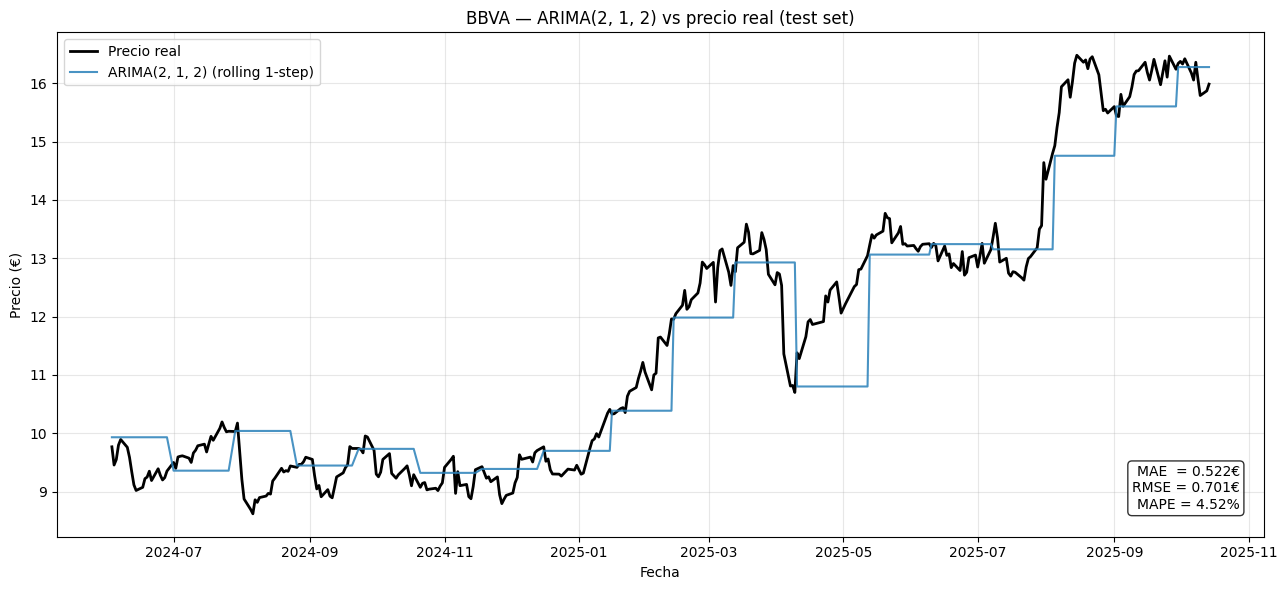

In [26]:
# ----- Gráfico: ARIMA vs realidad -----
fig, ax = plt.subplots(figsize=(13, 6))

# Precio real
ax.plot(test_serie.index, test_serie.values, color='black', lw=2, label='Precio real')

# Predicción ARIMA
ax.plot(arima_preds.index, arima_preds.values, color='#2980b9', lw=1.5,
        alpha=0.85, label=f'ARIMA{best_order} (rolling 1-step)')

ax.set_title(f'{TICKER_REG} — ARIMA{best_order} vs precio real (test set)')
ax.set_ylabel('Precio (€)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')

# Anotaciones de métricas
texto_metricas = (f"MAE  = {metrica_arima['MAE (€)']:.3f}€\n"
                  f"RMSE = {metrica_arima['RMSE (€)']:.3f}€\n"
                  f"MAPE = {metrica_arima['MAPE (%)']:.2f}%")
ax.text(0.98, 0.05, texto_metricas, transform=ax.transAxes,
        fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/10_arima_BBVA.png', bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# PASO 21 - Modelo B: LSTM (Red Neuronal Recurrente)
# ============================================================
# 21.1 - Preparación de datos para LSTM

# Filtramos BBVA y eliminamos NaN
df_bbva = (df[df['Ticker'] == TICKER_REG]
             .sort_values('Date')
             .set_index('Date')
             .dropna(subset=FEAT_COLS + ['Target_Price_30d']))

print(f"Shape df_bbva tras limpiar: {df_bbva.shape}")

# Las features que vamos a usar = las 15 features del Paso 15 + el precio Close
features_lstm = ['Close'] + FEAT_COLS
print(f"Total features para LSTM: {len(features_lstm)}")
print(f"  ({features_lstm[0]} + 15 features)")

# Matriz de inputs (X) y vector de targets (y)
X_full = df_bbva[features_lstm].values
y_full = df_bbva['Target_Price_30d'].values
dates_full = df_bbva.index

print(f"\nX_full shape: {X_full.shape}")  # (días, 16)
print(f"y_full shape: {y_full.shape}")    # (días,)

Shape df_bbva tras limpiar: (1191, 36)
Total features para LSTM: 16
  (Close + 15 features)

X_full shape: (1191, 16)
y_full shape: (1191,)


In [28]:
# ----- Escalado con MinMaxScaler (mejor para LSTM) -----

# Split temporal (igual que en clasificación)
train_mask = dates_full <  SPLIT_DATE
test_mask  = dates_full >= SPLIT_DATE

# Ajustamos los scalers SOLO con datos de train
x_scaler = MinMaxScaler()
x_scaler.fit(X_full[train_mask])  # ← solo train

y_scaler = MinMaxScaler()
y_scaler.fit(y_full[train_mask].reshape(-1, 1))  # ← solo train

# Aplicamos los scalers a TODO (train + test)
X_scaled = x_scaler.transform(X_full)
y_scaled = y_scaler.transform(y_full.reshape(-1, 1)).flatten()

print(f"X_scaled rango: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print(f"y_scaled rango: [{y_scaled.min():.3f}, {y_scaled.max():.3f}]")
print(f"\n✔ Datos escalados a [0, 1].")

X_scaled rango: [0.000, 2.215]
y_scaled rango: [0.000, 1.725]

✔ Datos escalados a [0, 1].


In [29]:
# ----- Crear secuencias de longitud WINDOW -----
WINDOW = 60  # ventana de 60 días

def make_sequences(X, y, window):
    """
    Convierte una serie continua en ventanas deslizantes para LSTM.

    Args:
        X: matriz (n_dias, n_features)
        y: vector (n_dias,) con los targets
        window: longitud de cada ventana

    Returns:
        Xs: tensor 3D (n_secuencias, window, n_features)
        ys: vector (n_secuencias,) con los targets correspondientes
    """
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])         # ventana de 60 días
        ys.append(y[i+window-1])          # target del último día de la ventana
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW)
dates_seq = dates_full[WINDOW-1:-1]  # alineamos las fechas

print(f"X_seq shape: {X_seq.shape}")  # (n_secuencias, 60, 16)
print(f"y_seq shape: {y_seq.shape}")
print(f"\nInterpretación:")
print(f"  - {X_seq.shape[0]} secuencias")
print(f"  - cada secuencia tiene {X_seq.shape[1]} días")
print(f"  - cada día tiene {X_seq.shape[2]} features")

# Split temporal de las secuencias
tr_mask_seq = dates_seq < SPLIT_DATE
te_mask_seq = dates_seq >= SPLIT_DATE

X_train_seq = X_seq[tr_mask_seq]
y_train_seq = y_seq[tr_mask_seq]
X_test_seq  = X_seq[te_mask_seq]
y_test_seq  = y_seq[te_mask_seq]

print(f"\nTrain: {X_train_seq.shape[0]:,} secuencias")
print(f"Test:  {X_test_seq.shape[0]:,} secuencias")

X_seq shape: (1131, 60, 16)
y_seq shape: (1131,)

Interpretación:
  - 1131 secuencias
  - cada secuencia tiene 60 días
  - cada día tiene 16 features

Train: 811 secuencias
Test:  320 secuencias


In [30]:
# ============================================================
# PASO 22 - Construcción y entrenamiento de la LSTM
# ============================================================

# Importamos TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras backend:      {tf.keras.backend.backend()}")

# Reproducibilidad: fijar semillas
tf.random.set_seed(42)
np.random.seed(42)

# ----- Construcción del modelo -----
n_features = X_train_seq.shape[2]  # debería ser 16

model = Sequential([
    # Capa LSTM 1: devuelve la secuencia entera para alimentar la siguiente LSTM
    LSTM(50, return_sequences=True, input_shape=(WINDOW, n_features)),
    Dropout(0.2),

    # Capa LSTM 2: devuelve solo el último output (vector, no secuencia)
    LSTM(50, return_sequences=False),
    Dropout(0.2),

    # Capa densa de transición
    Dense(25, activation='relu'),

    # Capa de salida: 1 neurona = el precio predicho
    Dense(1)
])

# Compilamos el modelo
model.compile(
    optimizer='adam',
    loss='mse',           # función de pérdida: Mean Squared Error
    metrics=['mae']       # también monitorizamos MAE durante el entrenamiento
)

# Mostramos la arquitectura
model.summary()

TensorFlow version: 2.19.0
Keras backend:      tensorflow


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        13,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,901 (136.33 KB)

 Trainable params: 34,901 (136.33 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ----- Entrenamiento del modelo -----

# Early stopping: para automáticamente si la val_loss no mejora en 10 épocas
early = EarlyStopping(
    monitor='val_loss',         # monitoriza el error en validation
    patience=10,                # espera 10 épocas sin mejora
    restore_best_weights=True   # al parar, recupera los mejores pesos
)

# Entrenamos
print("Entrenando LSTM... (esto puede tardar 1-3 minutos)\n")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,    # usa el 10% del train como validation
    epochs=50,
    batch_size=32,
    callbacks=[early],
    verbose=1                # muestra una línea por época
)

print(f"\n✔ Entrenamiento completado")
print(f"  Épocas ejecutadas: {len(history.history['loss'])}")
print(f"  Mejor val_loss:    {min(history.history['val_loss']):.6f}")

Entrenando LSTM... (esto puede tardar 1-3 minutos)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - loss: 0.0418 - mae: 0.1492 - val_loss: 0.1683 - val_mae: 0.4042
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0088 - mae: 0.0696 - val_loss: 0.0821 - val_mae: 0.2786
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0068 - mae: 0.0607 - val_loss: 0.0586 - val_mae: 0.2320
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0047 - mae: 0.0525 - val_loss: 0.0330 - val_mae: 0.1673
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0050 - mae: 0.0525 - val_loss: 0.0156 - val_mae: 0.1043
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0046 - mae: 0.0520 - val_loss: 0.0164 - val_mae: 0.1068
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0043 - mae: 0.0489 - val_loss: 0.0131 - val_mae: 0.0914
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0032 - mae: 0.0437 - val_loss: 0.0092 - val_mae: 0.0736
Epoch 9/50

In [32]:
# ============================================================
# PASO 23 - Predicciones LSTM, métricas y comparativa
# ============================================================

# ----- 1. Predicciones sobre el test set -----
print("Generando predicciones sobre el test set...")
yp_lstm_scaled = model.predict(X_test_seq, verbose=0).flatten()

# ----- 2. Desescalado -----
# Las predicciones salen en rango [0, 1], hay que volver a euros
yp_lstm    = y_scaler.inverse_transform(yp_lstm_scaled.reshape(-1, 1)).flatten()
y_test_real = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Fechas correspondientes a las secuencias de test
lstm_dates = dates_seq[te_mask_seq]

print(f"✔ Predicciones generadas: {len(yp_lstm):,}")
print(f"\nPrimeras 5 predicciones vs realidad:")
for i in range(5):
    print(f"  {lstm_dates[i].date()}  Real: {y_test_real[i]:6.3f}€  →  Pred: {yp_lstm[i]:6.3f}€  "
          f"(error: {yp_lstm[i] - y_test_real[i]:+.3f}€)")

Generando predicciones sobre el test set...
✔ Predicciones generadas: 320

Primeras 5 predicciones vs realidad:
  2024-06-03  Real:  9.814€  →  Pred:  9.798€  (error: -0.016€)
  2024-06-04  Real:  9.680€  →  Pred:  9.784€  (error: +0.104€)
  2024-06-05  Real:  9.818€  →  Pred:  9.774€  (error: -0.044€)
  2024-06-06  Real:  9.948€  →  Pred:  9.770€  (error: -0.178€)
  2024-06-07  Real:  9.880€  →  Pred:  9.764€  (error: -0.116€)


In [33]:
# ----- 3. Métricas LSTM -----
metrica_lstm = calcular_metricas_reg('LSTM', y_test_real, yp_lstm)

print("=" * 55)
print("MÉTRICAS — LSTM (Modelo B avanzado)")
print("=" * 55)
for k, v in metrica_lstm.items():
    print(f"  {k:12s}: {v}")

MÉTRICAS — LSTM (Modelo B avanzado)
  Modelo      : LSTM
  MAE (€)     : 3.0817
  RMSE (€)    : 4.0565
  MAPE (%)    : 22.71


In [34]:
# ----- 4. Comparativa ARIMA vs LSTM -----
comp_reg = pd.DataFrame([metrica_arima, metrica_lstm])

print("=" * 70)
print("COMPARATIVA — REGRESIÓN")
print("=" * 70)
print(comp_reg.to_string(index=False))

print(f"\n⚠ NOTA IMPORTANTE: las métricas no son directamente comparables porque:")
print(f"  - ARIMA predice 1 DÍA vista (rolling forecast)")
print(f"  - LSTM predice 30 DÍAS vista (sin reentrenar)")
print(f"\n  Por tanto, LSTM resuelve un problema 30× más difícil.")
print(f"  Su valor real está en su capacidad de capturar dirección,")
print(f"  no en su precisión absoluta de céntimos.")

COMPARATIVA — REGRESIÓN
      Modelo  MAE (€)  RMSE (€)  MAPE (%)
ARIMA(2,1,2)   0.5224    0.7008      4.52
        LSTM   3.0817    4.0565     22.71

⚠ NOTA IMPORTANTE: las métricas no son directamente comparables porque:
  - ARIMA predice 1 DÍA vista (rolling forecast)
  - LSTM predice 30 DÍAS vista (sin reentrenar)

  Por tanto, LSTM resuelve un problema 30× más difícil.
  Su valor real está en su capacidad de capturar dirección,
  no en su precisión absoluta de céntimos.


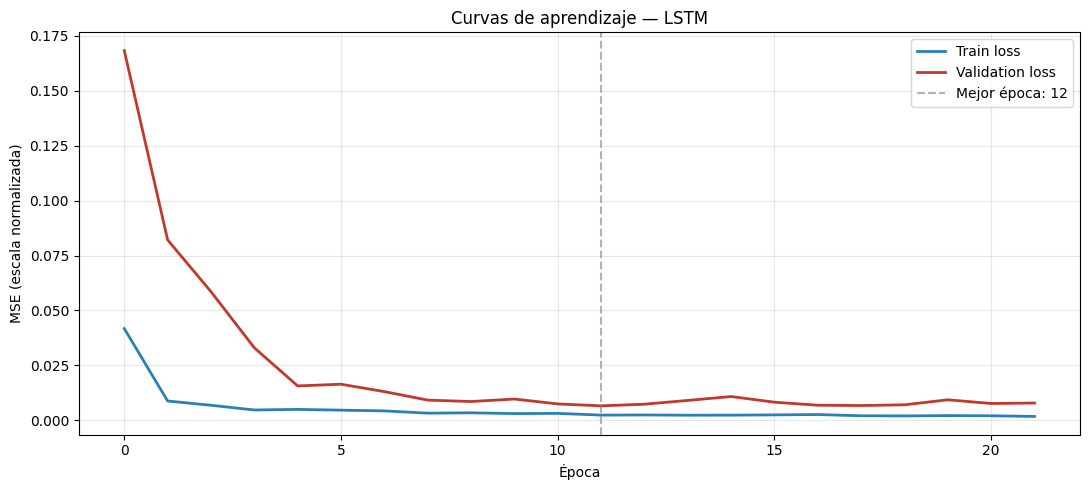

In [35]:
# ----- 5. Curvas de aprendizaje LSTM -----
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(history.history['loss'],     label='Train loss',      color='#2980b9', lw=2)
ax.plot(history.history['val_loss'], label='Validation loss', color='#c0392b', lw=2)

# Marcamos la mejor época
best_epoch = np.argmin(history.history['val_loss'])
ax.axvline(best_epoch, color='gray', ls='--', alpha=0.6,
           label=f'Mejor época: {best_epoch+1}')

ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.set_title('Curvas de aprendizaje — LSTM')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/11_lstm_curvas_aprendizaje.png', bbox_inches='tight')
plt.show()

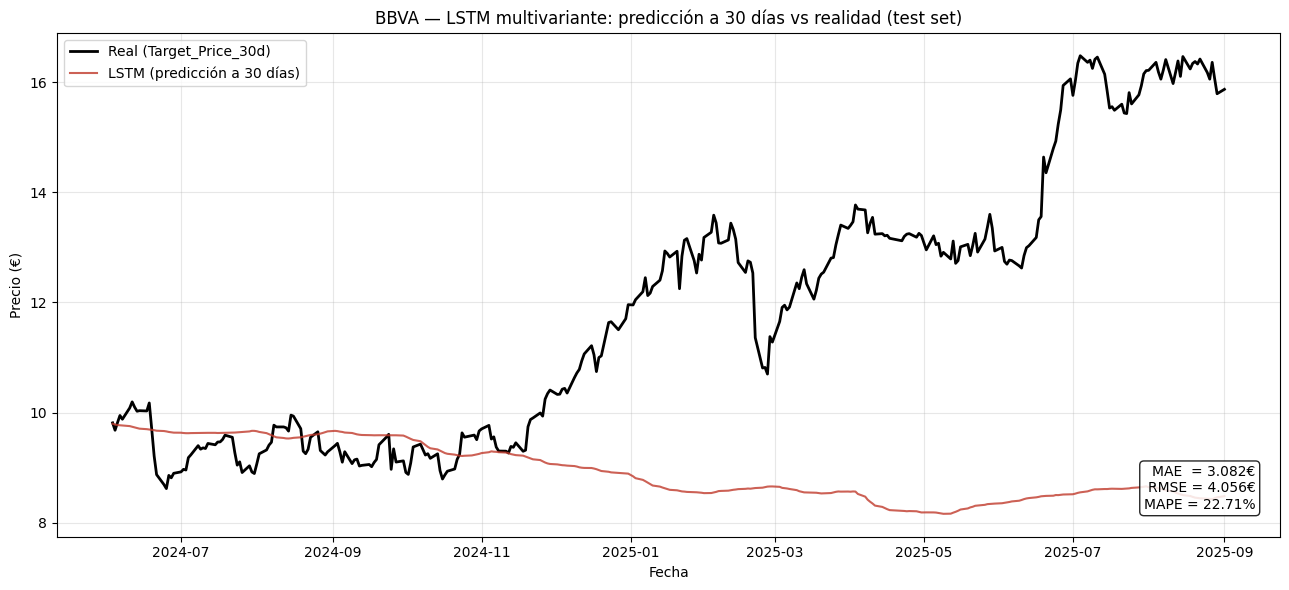

In [36]:
# ----- 6. Predicción LSTM vs realidad -----
fig, ax = plt.subplots(figsize=(13, 6))

# Precio real
ax.plot(lstm_dates, y_test_real, color='black', lw=2, label='Real (Target_Price_30d)')

# Predicción LSTM
ax.plot(lstm_dates, yp_lstm, color='#c0392b', lw=1.5, alpha=0.8, label='LSTM (predicción a 30 días)')

ax.set_title(f'{TICKER_REG} — LSTM multivariante: predicción a 30 días vs realidad (test set)')
ax.set_ylabel('Precio (€)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')

# Anotaciones de métricas
texto_metricas = (f"MAE  = {metrica_lstm['MAE (€)']:.3f}€\n"
                  f"RMSE = {metrica_lstm['RMSE (€)']:.3f}€\n"
                  f"MAPE = {metrica_lstm['MAPE (%)']:.2f}%")
ax.text(0.98, 0.05, texto_metricas, transform=ax.transAxes,
        fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/12_lstm_vs_real.png', bbox_inches='tight')
plt.show()

In [37]:
# ============================================================
# PASO 24 - Cierre del Pilar 2: comparativa final
# ============================================================

print("=" * 75)
print("RESUMEN FINAL — PILAR 2 (ANÁLISIS DEL DATO)")
print("=" * 75)

print("\n🎯 TAREA A — CLASIFICACIÓN DE RIESGO (caída >10% en 30 días)")
print("-" * 75)
print(comparativa.to_string(index=False))
print(f"\n   🏆 GANADOR: Logistic Regression (mejor F1 y recall)")

print("\n\n📈 TAREA B — REGRESIÓN DE PRECIO (a 30 días)")
print("-" * 75)
print(comp_reg.to_string(index=False))
print(f"\n   🏆 GANADOR (en métricas absolutas): ARIMA(2,1,2)")
print(f"   ⚠ Pero la comparativa NO es justa:")
print(f"      - ARIMA predice a 1 día con rolling forecast")
print(f"      - LSTM predice a 30 días sin reentrenar")
print(f"   La LSTM reveló limitaciones interesantes (distribution shift, eventos exógenos)")

RESUMEN FINAL — PILAR 2 (ANÁLISIS DEL DATO)

🎯 TAREA A — CLASIFICACIÓN DE RIESGO (caída >10% en 30 días)
---------------------------------------------------------------------------
             Modelo  Accuracy  Precision  Recall  F1-Score    AUC
Logistic Regression    0.8720     0.3363  0.3265    0.3314 0.6376
      Random Forest    0.8417     0.0814  0.0612    0.0699 0.6267

   🏆 GANADOR: Logistic Regression (mejor F1 y recall)


📈 TAREA B — REGRESIÓN DE PRECIO (a 30 días)
---------------------------------------------------------------------------
      Modelo  MAE (€)  RMSE (€)  MAPE (%)
ARIMA(2,1,2)   0.5224    0.7008      4.52
        LSTM   3.0817    4.0565     22.71

   🏆 GANADOR (en métricas absolutas): ARIMA(2,1,2)
   ⚠ Pero la comparativa NO es justa:
      - ARIMA predice a 1 día con rolling forecast
      - LSTM predice a 30 días sin reentrenar
   La LSTM reveló limitaciones interesantes (distribution shift, eventos exógenos)


In [38]:
# ----- Guardar predicciones para uso en Pilar 3 -----

# Predicciones de clasificación (Logistic, modelo ganador)
pred_clasif = test[['Date', 'Ticker', 'Close', 'Target_Risk']].copy()
pred_clasif['pred_logistic']  = y_pred_lr
pred_clasif['proba_logistic'] = y_pred_proba_lr
pred_clasif['pred_rf']        = y_pred_rf
pred_clasif['proba_rf']       = y_pred_proba_rf

ruta_clasif = f'{DATA_DIR}/predicciones_clasificacion.csv'
pred_clasif.to_csv(ruta_clasif, index=False)
print(f"✔ Predicciones de clasificación guardadas: {ruta_clasif}")
print(f"  Shape: {pred_clasif.shape}")

# Predicciones de regresión (ARIMA + LSTM, para BBVA)
pred_reg_arima = pd.DataFrame({
    'Date':       test_serie.index,
    'Ticker':     TICKER_REG,
    'Real':       test_serie.values,
    'Pred_ARIMA': arima_preds.values
})
pred_reg_lstm = pd.DataFrame({
    'Date':       lstm_dates,
    'Ticker':     TICKER_REG,
    'Real':       y_test_real,
    'Pred_LSTM':  yp_lstm
})

ruta_arima = f'{DATA_DIR}/predicciones_arima_BBVA.csv'
ruta_lstm  = f'{DATA_DIR}/predicciones_lstm_BBVA.csv'
pred_reg_arima.to_csv(ruta_arima, index=False)
pred_reg_lstm.to_csv(ruta_lstm, index=False)
print(f"\n✔ Predicciones ARIMA guardadas: {ruta_arima}")
print(f"✔ Predicciones LSTM guardadas:  {ruta_lstm}")

✔ Predicciones de clasificación guardadas: /content/drive/MyDrive/TFG_Lorente/output/predicciones_clasificacion.csv
  Shape: (3531, 8)

✔ Predicciones ARIMA guardadas: /content/drive/MyDrive/TFG_Lorente/output/predicciones_arima_BBVA.csv
✔ Predicciones LSTM guardadas:  /content/drive/MyDrive/TFG_Lorente/output/predicciones_lstm_BBVA.csv


In [1]:
# ----- Tabla resumen final para memoria -----
print("\n" + "=" * 75)
print("📋 TABLA FINAL DE MÉTRICAS — PILAR 2")
print("=" * 75)

# Tabla de clasificación
print("\nCLASIFICACIÓN DE RIESGO")
print("─" * 60)
print(f"{'Modelo':<25}{'F1':<10}{'AUC':<10}{'Recall':<10}")
print("─" * 60)
print(f"{'Logistic Regression':<25}{0.331:<10.3f}{0.638:<10.3f}{0.327:<10.3f}  ← 🏆")
print(f"{'Random Forest':<25}{0.070:<10.3f}{0.627:<10.3f}{0.061:<10.3f}")

# Tabla de regresión
print("\nREGRESIÓN PRECIO 30d (BBVA)")
print("─" * 60)
print(f"{'Modelo':<25}{'MAE':<10}{'RMSE':<10}{'MAPE':<10}")
print("─" * 60)
print(f"{'ARIMA(2,1,2)':<25}{0.522:<10.3f}{0.701:<10.3f}{4.52:<10.2f}  ← 🏆 (1d)")
print(f"{'LSTM multivariante':<25}{3.082:<10.3f}{4.056:<10.3f}{22.71:<10.2f}  (30d)")
print()
print("⚠ Las métricas de regresión NO son comparables directamente:")
print("  ARIMA: rolling forecast a 1 día | LSTM: forecast a 30 días sin reentrenar")


📋 TABLA FINAL DE MÉTRICAS — PILAR 2

CLASIFICACIÓN DE RIESGO
────────────────────────────────────────────────────────────
Modelo                   F1        AUC       Recall    
────────────────────────────────────────────────────────────
Logistic Regression      0.331     0.638     0.327       ← 🏆
Random Forest            0.070     0.627     0.061     

REGRESIÓN PRECIO 30d (BBVA)
────────────────────────────────────────────────────────────
Modelo                   MAE       RMSE      MAPE      
────────────────────────────────────────────────────────────
ARIMA(2,1,2)             0.522     0.701     4.52        ← 🏆 (1d)
LSTM multivariante       3.082     4.056     22.71       (30d)

⚠ Las métricas de regresión NO son comparables directamente:
  ARIMA: rolling forecast a 1 día | LSTM: forecast a 30 días sin reentrenar
